In [1]:
import os
import numpy as np

import jax
import jax.numpy as jnp
from jax import jacfwd, vmap
from functools import partial
from typing import NamedTuple, Sequence, Callable

import flax.linen as nn
import optax
from soap_jax import soap

import time
import scipy.io
import matplotlib.pyplot as plt

from flax import serialization

from Utilities_pinn_burgers1d_moving import *

Test grid: Nt=513, Nx=513
Interface x=0.50000000, index=256


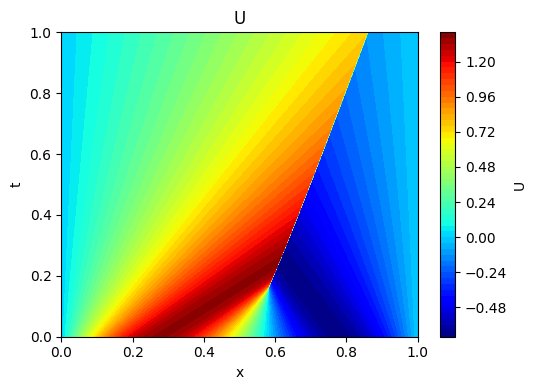

In [2]:
# 1. Data
data = scipy.io.loadmat("burgers_godunov2.mat")

#data = scipy.io.loadmat("burgers_riemann.mat")

U0 = jnp.asarray(data["U"][::2,::2])
X0 = jnp.asarray(data["X"][::2,::2])
T0 = jnp.asarray(data["T"][::2,::2])

Nt_test, Nx_test = U0.shape
t_test = T0.reshape(-1)
x_test = X0.reshape(-1)
test_inputs = jnp.stack([t_test, x_test], axis=-1)
test_labels = U0.reshape(-1, 1)

x_unique = np.unique(np.asarray(X0))
interface_idx = int(np.argmin(np.abs(x_unique - 0.5)))
interface_x = float(x_unique[interface_idx])

print(f"Test grid: Nt={Nt_test}, Nx={Nx_test}")
print(f"Interface x={interface_x:.8f}, index={interface_idx}")

plt.figure(figsize=(5.5, 4))
plt.contourf(X0, T0, U0, levels=50, cmap='jet')
plt.colorbar(label='U')
plt.xlabel('x')
plt.ylabel('t')
plt.title('U')
plt.tight_layout()
plt.show()

In [3]:
# 2. Keep the PDE initialization/training keys aligned with TAL-PINN.
seed = 40
save_path = "pinn_burgers_movinge10.msgpack"

key = jax.random.PRNGKey(seed)
key_pde_init, _, key_train = jax.random.split(key, 3)

# 3. Vanilla PINN on physical coordinates [t, x]
pde_net = FNN_fourier(layer_sizes=[40, 40, 1], fourier_dim=20)
pde_params = pde_net.init(key_pde_init, jnp.ones((2,), dtype=T0.dtype))

pde_optimizer = soap(learning_rate=3.0e-3, b1=0.95, b2=0.95, weight_decay=0.01, precondition_frequency=10, precondition_1d=False)

pde_loss_grad_fn = create_pde_loss_grad_fn(pde_net)
pde_minibatch_fn = create_pde_minibatch_fn(IC_Burgers, BC_Burgers)
eval_fn = create_eval_fn(pde_net, nx_test=Nx_test, interface_idx=interface_idx, interface_mode="drop")

[Vanilla PINN] JIT warm-up finished.
[Vanilla PINN] iter = 00000, time = 0.00s | mse = 5.62e-01, rl2 = 1.25e+00
[Vanilla PINN] iter = 00100, time = 0.56s, loss = 6.16e-01 | mse = 6.32e-02, rl2 = 4.21e-01
[Vanilla PINN] iter = 00200, time = 0.85s, loss = 5.41e-01 | mse = 5.38e-02, rl2 = 3.88e-01
[Vanilla PINN] iter = 00300, time = 1.15s, loss = 5.16e-01 | mse = 4.96e-02, rl2 = 3.73e-01
[Vanilla PINN] iter = 00400, time = 1.44s, loss = 4.96e-01 | mse = 4.68e-02, rl2 = 3.62e-01
[Vanilla PINN] iter = 00500, time = 1.74s, loss = 4.90e-01 | mse = 4.54e-02, rl2 = 3.57e-01
[Vanilla PINN] iter = 00600, time = 2.04s, loss = 4.84e-01 | mse = 4.38e-02, rl2 = 3.50e-01
[Vanilla PINN] iter = 00700, time = 2.33s, loss = 4.77e-01 | mse = 4.15e-02, rl2 = 3.41e-01
[Vanilla PINN] iter = 00800, time = 2.62s, loss = 4.72e-01 | mse = 4.02e-02, rl2 = 3.36e-01
[Vanilla PINN] iter = 00900, time = 2.92s, loss = 4.56e-01 | mse = 3.93e-02, rl2 = 3.32e-01
[Vanilla PINN] iter = 01000, time = 3.21s, loss = 4.51e-01 |

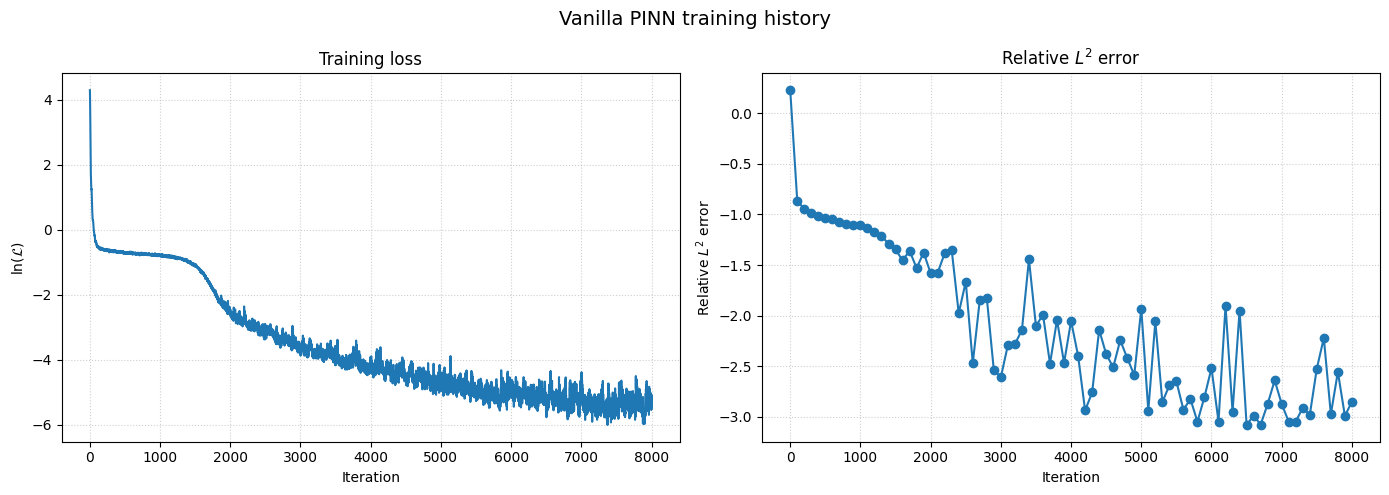

Plotting... Test grid shape: nt=513, nx=513
Interface detected at x = 0.50000000, index = 256
MSE = 1.196479e-03
 RL2 = 5.789473e-02


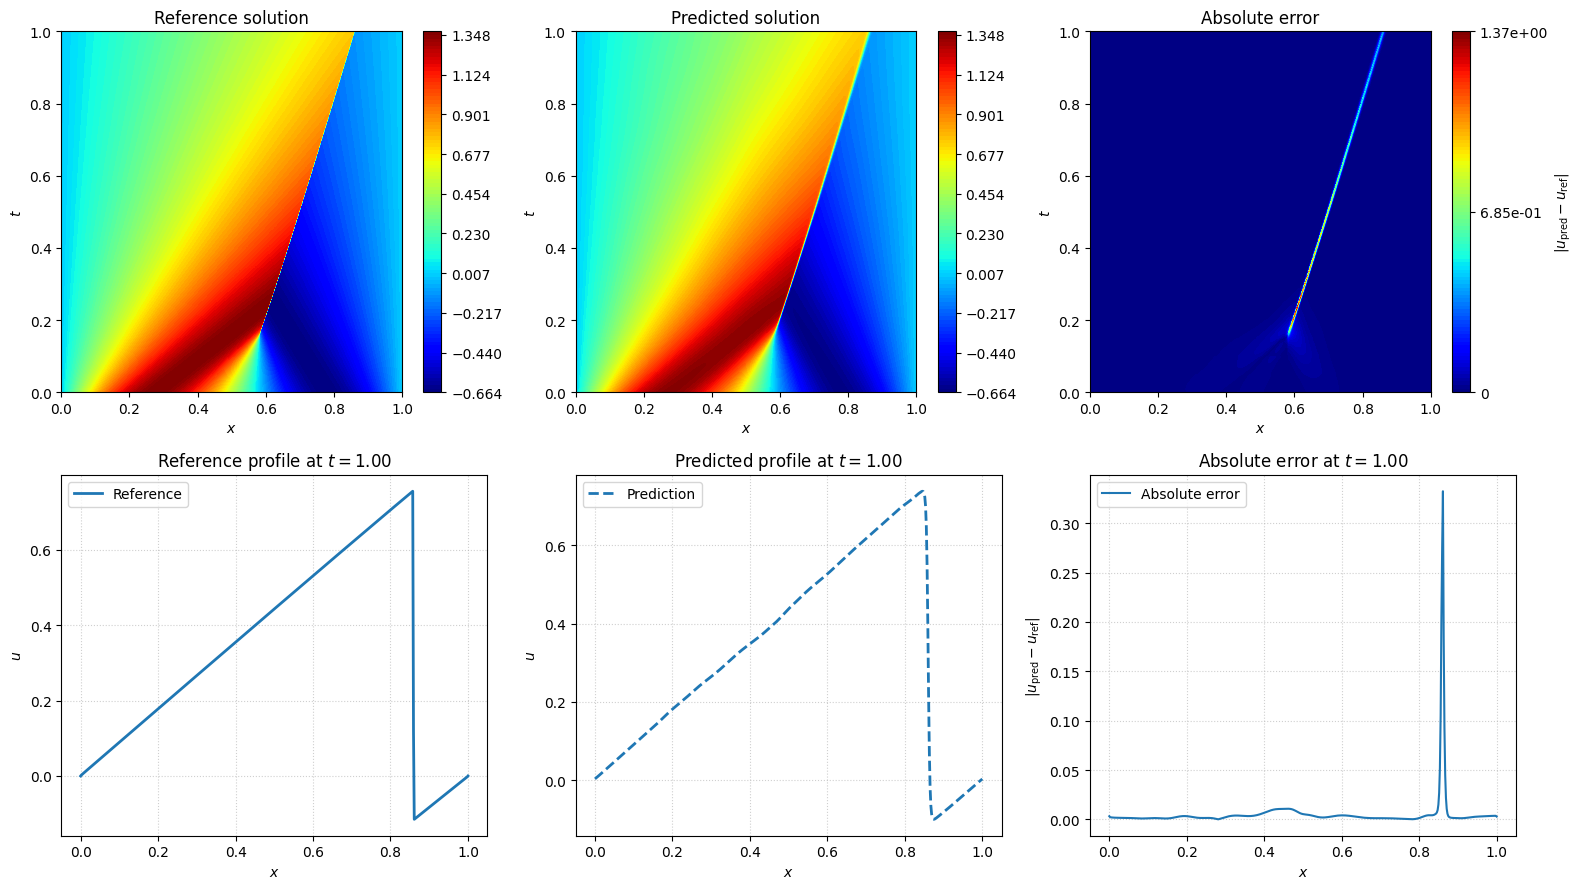

(np.float32(0.0011964793), np.float32(0.057894733))

In [4]:
# 4. One direct training stage at the target viscosity.
pde_params, key_train, history = train_pde_stage(stage_name="Vanilla PINN", pde_params=pde_params, pde_optimizer=pde_optimizer, pde_loss_grad_fn=pde_loss_grad_fn, pde_minibatch_fn=pde_minibatch_fn,
    eval_fn=eval_fn, test_inputs=test_inputs, test_labels=test_labels,
    key=key_train, nu=1.0e-3, max_iters=8000, pts_pde=10000, pts_ics=1000, pts_bcs=1000, max_runtime=10000.0, eval_every=100)

save_training_results(pde_params=pde_params, pde_history=history, checkpoint_path=save_path)

plot_training_history(history, metric="rl2", title="Vanilla PINN training history")
plot_evaluation(params=pde_params, model=pde_net, t_test=t_test, x_test=x_test, labels_test=test_labels, interface_x=interface_x, 
    metric_interface_mode="drop", plot_interface_mode="none")